# Regressions: what predicts a denial, and what predicts a fight?

Two logistic models on the extracted record. Observational, so these are
associations, not causal claims — and the outcome variables are extraction-
derived (see caveats at the end). Standard errors are clustered by meeting:
votes and license decisions within one night are not independent.

1. **License denial** — outcome: recorded action/recommendation contains
   "denial"; predictors: application type, venue features, era.
2. **Contested vote** — outcome: at least one "no"; predictors: topic,
   attendance, year.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

## Model 1: license denial

Only records with a recorded action or committee recommendation (n≈1,310;
the batch-approved bulk of the docket never gets an individual disposition
and is excluded — this models *decided* items).

In [2]:
lic = q("""
    SELECT l.meeting_id, year(m.date) AS yr, l.application_type, l.features,
           CASE WHEN lower(coalesce(l.board_action,'') ||
                coalesce(l.committee_recommendation,'')) LIKE '%den%'
                THEN 1 ELSE 0 END AS denied
    FROM licenses l JOIN meetings m USING (meeting_id)
    WHERE l.board_action IS NOT NULL OR l.committee_recommendation IS NOT NULL
""")
for feat in ("rooftop", "sidewalk_cafe", "patron_dancing", "live_music",
             "outdoor_seating", "backyard"):
    lic[f"f_{feat}"] = lic.features.map(lambda fs, k=feat: int(any(k in f for f in fs)))
lic["app"] = lic.application_type.where(
    lic.application_type.isin(["new", "renewal", "alteration", "corporate_change"]), "other")
lic["era"] = pd.cut(lic.yr, [2015, 2019, 2022, 2027],
                    labels=["2016-19", "2020-22", "2023-26"])
print(lic.denied.mean().round(3), "base denial rate,", len(lic), "records")

m1 = smf.logit(
    "denied ~ C(app, Treatment('renewal')) + f_rooftop + f_patron_dancing "
    "+ f_live_music + f_sidewalk_cafe + f_backyard + C(era)",
    data=lic).fit(disp=0, cov_type="cluster", cov_kwds={"groups": lic.meeting_id})
print(m1.summary2().tables[1].round(3))

0.118 base denial rate, 1310 records
                                                  Coef.  Std.Err.      z  \
Intercept                                        -4.096     0.571 -7.179   
C(app, Treatment('renewal'))[T.alteration]        3.062     0.636  4.813   
C(app, Treatment('renewal'))[T.corporate_change]  3.084     0.641  4.811   
C(app, Treatment('renewal'))[T.new]               2.523     0.594  4.247   
C(app, Treatment('renewal'))[T.other]             2.742     0.662  4.141   
C(era)[T.2020-22]                                 0.307     0.403  0.762   
C(era)[T.2023-26]                                 0.101     0.396  0.255   
f_rooftop                                        -0.083     0.720 -0.115   
f_patron_dancing                                 -0.849     1.015 -0.837   
f_live_music                                      0.429     0.747  0.574   
f_sidewalk_cafe                                   0.138     0.453  0.305   
f_backyard                                       -0

In [3]:
or_table = pd.DataFrame({
    "odds_ratio": np.exp(m1.params),
    "ci_low": np.exp(m1.conf_int()[0]),
    "ci_high": np.exp(m1.conf_int()[1]),
    "p": m1.pvalues,
}).round(3).sort_values("odds_ratio", ascending=False)
or_table

,odds_ratio,ci_low,ci_high,p
"C(app, Treatment('renewal'))[T.corporate_change]",21.845,6.219,76.736,0.000
"C(app, Treatment('renewal'))[T.alteration]",21.365,6.141,74.335,0.000
"C(app, Treatment('renewal'))[T.other]",15.512,4.238,56.784,0.000
"C(app, Treatment('renewal'))[T.new]",12.467,3.891,39.947,0.000
f_live_music,1.535,0.355,6.639,0.566
C(era)[T.2020-22],1.359,0.617,2.993,0.446
f_sidewalk_cafe,1.149,0.472,2.793,0.760
C(era)[T.2023-26],1.106,0.509,2.402,0.799
f_backyard,0.986,0.104,9.360,0.990
f_rooftop,0.921,0.225,3.772,0.909


## Model 2: contested votes

All tallied votes (voice votes excluded — no tally to contest).

In [4]:
v = q("""
    SELECT v.meeting_id, year(m.date) AS yr, v.topic_category,
           m.attendance_count,
           CASE WHEN v.no > 0 THEN 1 ELSE 0 END AS contested
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.yes + v.no > 0 AND m.attendance_count IS NOT NULL
""")
v["topic"] = v.topic_category.where(
    v.topic_category.isin(["land_use", "liquor", "transportation", "internal", "parks"]),
    "other")
m2 = smf.logit(
    "contested ~ C(topic, Treatment('liquor')) + attendance_count + I(yr - 2016)",
    data=v).fit(disp=0, cov_type="cluster", cov_kwds={"groups": v.meeting_id})
or2 = pd.DataFrame({
    "odds_ratio": np.exp(m2.params),
    "ci_low": np.exp(m2.conf_int()[0]),
    "ci_high": np.exp(m2.conf_int()[1]),
    "p": m2.pvalues,
}).round(3)
print(f"{len(v)} votes, base contested rate {v.contested.mean():.1%}")
or2

1142 votes, base contested rate 20.0%


,odds_ratio,ci_low,ci_high,p
Intercept,0.805,0.274,2.370,0.694
"C(topic, Treatment('liquor'))[T.internal]",0.310,0.124,0.777,0.012
"C(topic, Treatment('liquor'))[T.land_use]",1.034,0.440,2.429,0.938
"C(topic, Treatment('liquor'))[T.other]",0.367,0.139,0.969,0.043
"C(topic, Treatment('liquor'))[T.parks]",0.230,0.072,0.731,0.013
"C(topic, Treatment('liquor'))[T.transportation]",0.609,0.232,1.601,0.315
attendance_count,0.977,0.928,1.029,0.377
I(yr - 2016),0.992,0.908,1.084,0.863


## Model 3: does showing up work? Opposition testimony vs outcomes (waterfront corridor)

Links public-session opposition to specific license applications by street
address (house number + street-name token, testimony within 90 days before
the decision), then compares denial rates. Scoped to the **waterfront
corridor** — Kent, Franklin, Quay, West, Commercial, River, Wythe — the
blocks where the park fight, the nightlife fights, and the towers all live.
District-wide rates shown in gray for context.

Linkage caveats: only testimony specific enough to name an address links
(selects for organized opposition), and venues that draw opposition may
differ in ways the board also dislikes — association, not causation.

In [5]:
import re
from collections import defaultdict
from scipy.stats import fisher_exact

WATERFRONT_STREETS = ("kent", "franklin", "quay", "west st", "west street",
                      "commercial", "river st", "river street", "wythe")
STREET_STOP = {"street", "st", "avenue", "ave", "place", "pl", "road", "rd", "blvd"}

def addr_keys(text):
    out = set()
    for num, name in re.findall(
        r"(\d{1,4})[- ]?[A-Za-z]? ([A-Za-z][A-Za-z0-9 ]{2,28}?)"
        r"(?:,|\.|$| \(|;| Street| St\b| Avenue| Ave\b| Place| Pl\b| Road| Blvd)",
        str(text)):
        toks = [t.lower() for t in name.split() if t.lower() not in STREET_STOP]
        if toks:
            out.add((num, toks[-1]))
    return out

def on_waterfront(addr):
    a = str(addr).lower()
    return any(s in a for s in WATERFRONT_STREETS)

lic3 = q("""
    SELECT l.meeting_id, m.date, l.address, l.application_type,
           lower(coalesce(l.board_action,'') || ' ' ||
                 coalesce(l.committee_recommendation,'')) AS act
    FROM licenses l JOIN meetings m USING (meeting_id)
    WHERE l.board_action IS NOT NULL OR l.committee_recommendation IS NOT NULL
""")
spk3 = q("""
    SELECT m.date, s.topic FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE s.position = 'against'
""")
speech = defaultdict(list)
for _, r in spk3.iterrows():
    for k in addr_keys(r.topic):
        speech[k].append(r.date)

def opposed(row):
    return any(0 <= (row.date - sd).days <= 90
               for k in addr_keys(row.address) for sd in speech.get(k, []))

lic3["opposed"] = lic3.apply(opposed, axis=1)
lic3["denied"] = lic3.act.str.contains("den").astype(int)
lic3["corridor"] = lic3.address.map(on_waterfront)

def rate(df):
    return df.denied.sum(), len(df)

groups = {
    "corridor_opp":   rate(lic3[lic3.corridor & lic3.opposed]),
    "corridor_unopp": rate(lic3[lic3.corridor & ~lic3.opposed]),
    "district_opp":   rate(lic3[lic3.opposed]),
    "district_unopp": rate(lic3[~lic3.opposed]),
}
for k, (d, n) in groups.items():
    print(f"{k:15} {d:>3}/{n:<5} = {d/n:.1%}")
co, cu = groups["corridor_opp"], groups["corridor_unopp"]
odds, p = fisher_exact([[co[0], co[1]-co[0]], [cu[0], cu[1]-cu[0]]])
print(f"corridor Fisher exact: OR={odds:.2f}, p={p:.4f}")

corridor_opp      2/3     = 66.7%
corridor_unopp   14/166   = 8.4%
district_opp     11/24    = 45.8%
district_unopp  143/1286  = 11.1%
corridor Fisher exact: OR=21.71, p=0.0239


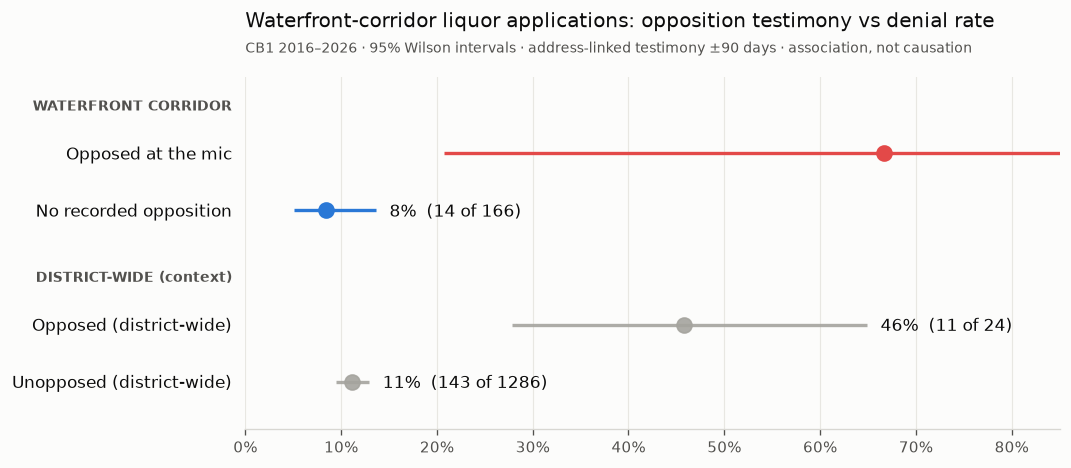

In [6]:
from statsmodels.stats.proportion import proportion_confint

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#a5a49e"

rows = [
    ("Opposed at the mic",      *groups["corridor_opp"],   RED,  1.0),
    ("No recorded opposition",  *groups["corridor_unopp"], BLUE, 1.0),
    ("Opposed (district-wide)",     *groups["district_opp"],   GRAY, 0.9),
    ("Unopposed (district-wide)",   *groups["district_unopp"], GRAY, 0.9),
]
fig, ax = plt.subplots(figsize=(9.5, 4.0), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ys = [3.3, 2.7, 1.5, 0.9]
for (label, k, n, color, alpha), y in zip(rows, ys):
    pr = k / n
    lo, hi = proportion_confint(k, n, method="wilson")
    ax.hlines(y, lo, hi, color=color, lw=2, alpha=alpha)
    ax.plot([pr], [y], "o", ms=9, color=color, alpha=alpha, zorder=3)
    ax.annotate(f"{pr:.0%}  ({k} of {n})", (hi, y), xytext=(8, -1),
                textcoords="offset points", va="center", fontsize=10, color=INK)
    ax.annotate(label, (0, y), xytext=(-8, -1), textcoords="offset points",
                ha="right", va="center", fontsize=10, color=INK)
ax.annotate("WATERFRONT CORRIDOR", (0, 3.75), xytext=(-8, 0),
            textcoords="offset points", ha="right", fontsize=8.5,
            color=INK2, fontweight="bold")
ax.annotate("DISTRICT-WIDE (context)", (0, 1.95), xytext=(-8, 0),
            textcoords="offset points", ha="right", fontsize=8.5,
            color=INK2, fontweight="bold")
ax.set_xlim(0, 0.85); ax.set_ylim(0.4, 4.1); ax.set_yticks([])
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.tick_params(colors=INK2, labelsize=9)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="x", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("Waterfront-corridor liquor applications: opposition testimony vs denial rate",
             fontsize=12, color=INK, loc="left", pad=30)
ax.text(0, 1.07, "CB1 2016–2026 · 95% Wilson intervals · address-linked testimony ±90 days · association, not causation",
        transform=ax.transAxes, fontsize=8.5, color=INK2)
plt.tight_layout(); plt.subplots_adjust(left=0.27)

## Caveats (read before quoting)

- **Selection**: model 1 only sees items with a recorded disposition —
  the uncontroversial batch-approved majority is invisible. Effects are
  "among decided items."
- **Extraction noise**: outcomes and features are model-extracted; the
  golden-set eval gates tallies, but `features` and free-text actions are
  softer fields.
- **No causal reading**: "rooftop predicts denial" ≠ "rooftops cause
  denials" — venues seeking risky features differ in unobserved ways.
- Cluster-robust SEs by meeting; n is modest — treat p-values near 0.05
  as suggestive.